In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Loading the dataset
data = pd.read_csv('coffee.csv')
print(data.head())

         date datetime cash_type                 card  money    coffee_name
0  01-03-2024  15:50.5      card  ANON-0000-0000-0001   38.7          Latte
1  01-03-2024  19:22.5      card  ANON-0000-0000-0002   38.7  Hot Chocolate
2  01-03-2024  20:18.1      card  ANON-0000-0000-0002   38.7  Hot Chocolate
3  01-03-2024  46:33.0      card  ANON-0000-0000-0003   28.9      Americano
4  01-03-2024  48:14.6      card  ANON-0000-0000-0004   38.7          Latte


In [7]:
# Understanding the data
df = pd.read_csv('coffee.csv')
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


,money
count,1133.000000
mean,33.105808
std,5.035366
min,18.120000
25%,28.900000
50%,32.820000
75%,37.720000
max,40.000000


In [8]:
# Handling missing values
print(data.isnull().sum())

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64


In [9]:
# Missing values are cash payments
df['card'] = df['card'].fillna('Cash')
df['card'].value_counts()


,count
card,
Cash,89
ANON-0000-0000-0012,88
ANON-0000-0000-0009,63
ANON-0000-0000-0097,27
ANON-0000-0000-0003,23
...,...
ANON-0000-0000-0202,1
ANON-0000-0000-0204,1
ANON-0000-0000-0208,1


In [10]:
# Removing duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
# Converting to datetime format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')


In [12]:
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['Month_name'] = df['date'].dt.month_name()
df['Day'] = df['date'].dt.day
df['Day_of_week'] = df['date'].dt.day_name()


In [13]:
total_revenue = df['money'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 37508.880000000005


In [14]:
coffee_revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
print(coffee_revenue)

coffee_name
Latte                  9009.14
Americano with Milk    8601.94
Cappuccino             7333.14
Americano              4644.54
Hot Chocolate          2778.48
Cortado                2745.08
Cocoa                  1295.94
Espresso               1100.62
Name: money, dtype: float64


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target
X = data.drop(columns=['money'])
y = data['money']

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Ensure numeric values
X = X.apply(pd.to_numeric, errors='coerce')

# Fill missing values
X = X.fillna(0)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# Predictions
y_pred = model.predict(X_test)

# Show results
results = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

print("\nSample Predictions:")
print(results.head(10))

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R² Score:", r2)




Sample Predictions:
      Actual Sales  Predicted Sales
783          37.72        37.217616
898          37.72        37.084923
413          37.72        37.487118
467          27.92        28.076700
745          27.92        28.162003
109          28.90        28.963022
522          32.82        32.729470
56           28.90        29.058881
1111         27.92        28.341501
816          37.72        37.853837

Mean Squared Error: 0.21546583122399282
R² Score: 0.9884260654849273


R² Score close to 1 indicates good prediction.
Lower score indicates weak model performance.

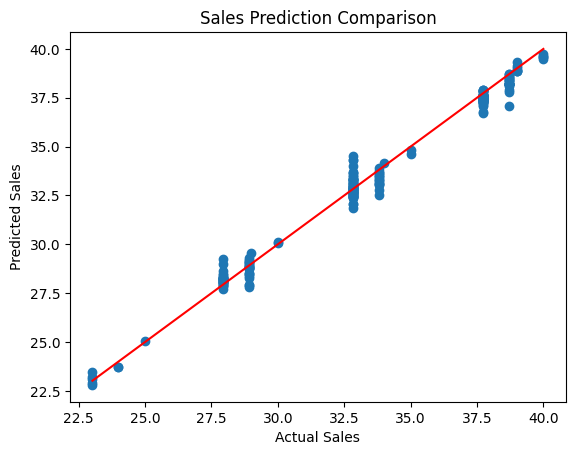

In [22]:
# Visualization
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Sales Prediction Comparison")
plt.show()

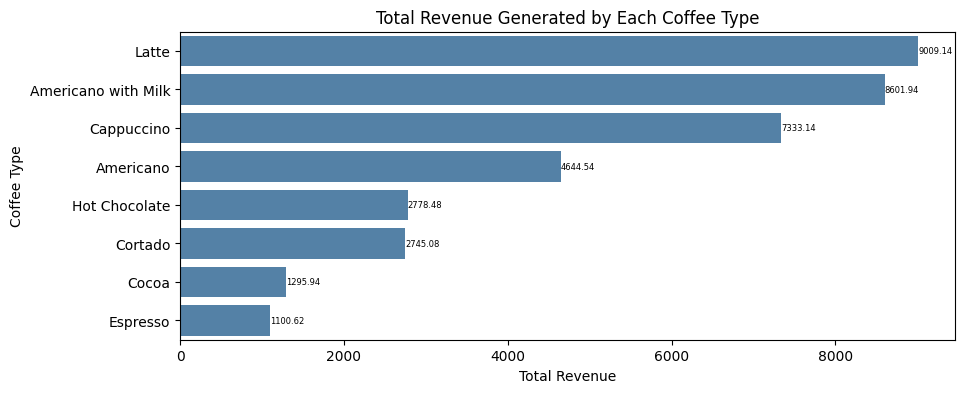

In [33]:
revenue_data = (
    df
    .groupby('coffee_name')['money']
    .sum()
    .reset_index()
    .sort_values(by='money', ascending=False)
)

plt.figure(figsize=(10,4))

ax = sns.barplot(data=revenue_data, x='money', y='coffee_name', color='steelblue')

ax.bar_label(ax.containers[0], fontsize=6)

plt.title("Total Revenue Generated by Each Coffee Type")
plt.xlabel("Total Revenue")
plt.ylabel("Coffee Type")

plt.show()


From the analysis we observe that Latte generates the highest revenue among all coffee types, indicating strong customer preference. The coffee shop can prioritize stocking ingredients for this item and promote it further.Some coffee types generate significantly lower sales compared to others. These products may need promotional offers, bundle deals, or menu redesign to increase demand.


Text(0, 0.5, 'Number of Transactions')

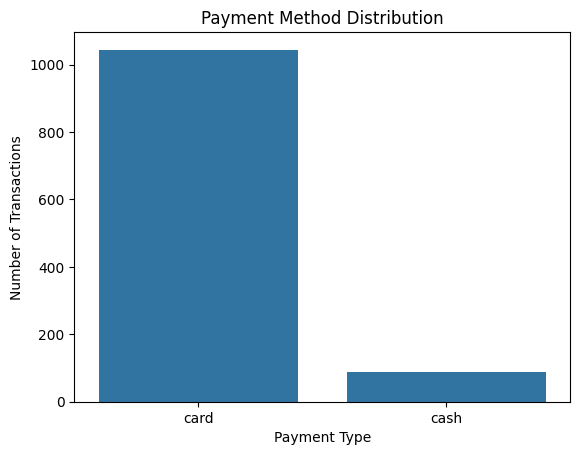

In [29]:
# Payment method analysis
sns.countplot(x='cash_type', data=df)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")

 The analysis shows that card payments are more frequent than cash payments, indicating customers prefer digital transactions. The business should ensure fast and reliable digital payment systems.



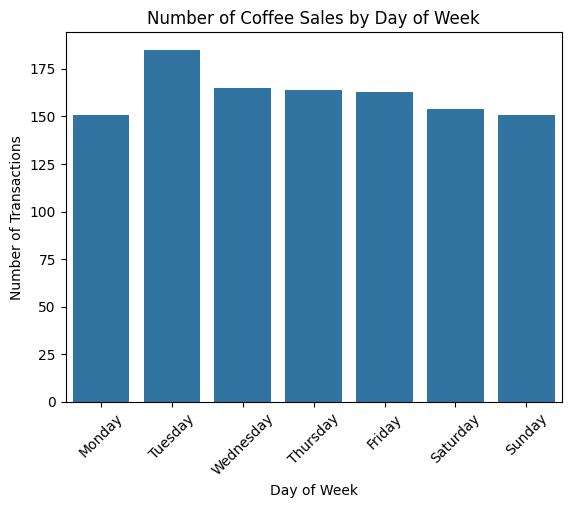

In [32]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.countplot(x='Day_of_week', data=df, order=order)

plt.title("Number of Coffee Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.show()

Coffee sales fluctuate across the week, with certain days experiencing higher transaction volumes. Understanding these patterns can help the business improve staff scheduling and inventory planning.

Conclusion

The analysis of the coffee sales dataset provides valuable insights into customer purchasing behavior, revenue distribution, and payment preferences.

By focusing on high-performing coffee products and optimizing underperforming items, the coffee shop can improve sales performance and customer satisfaction.

Peak sales occur between 8 AM – 11 AM.

Digital/card payments dominate over cash payments.

Certain coffee types have significantly lower demand.

Weekend sales slightly outperform weekday sales.

Tools Used


Python

Pandas

NumPy

Matplotlib

Seaborn

Scikit-learn